# Homework 3: Survival Analysis and Customer Lifetime Value

**Author:** Anna Asatryan  
**Course:** DS223 – Marketing Analytics

---

This notebook runs the full pipeline from `survival_analysis.py` and displays the resulting tables, figures, and interpretation inline.  
Execute top to bottom, or run `python survival_analysis.py` directly to regenerate all outputs.

In [1]:
import sys
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Ensure the script is importable from this notebook's location
sys.path.insert(0, str(Path(".").resolve()))
from survival_analysis import main, OUTPUT_DIR, IMG_DIR

# Run the full pipeline (idempotent – safe to re-run)
main()

Survival analysis completed.
Selected model: Log-Normal AFT
Significant features retained: ['address', 'age', 'custcat_E-service', 'custcat_Plus service', 'custcat_Total service', 'internet_Yes', 'marital_Unmarried', 'voice_Yes']
Outputs saved to: /Users/annaasatryan/Desktop/DS223/Survival_Analysis/output
Figures saved to: /Users/annaasatryan/Desktop/DS223/Survival_Analysis/img


## 1. Dataset Overview

In [2]:
import pandas as pd
df = pd.read_csv("telco.csv")
print(f"Shape: {df.shape}  |  Churn rate: {(df['churn']=='Yes').mean():.1%}  |  Tenure range: {df['tenure'].min()}–{df['tenure'].max()} months")
df.head()

Shape: (1000, 15)  |  Churn rate: 27.4%  |  Tenure range: 1–72 months


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
region,1000,3,Zone 3,344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,1000.0,NaN,NaN,NaN,35.526,21.359812,1.0,17.0,34.0,54.0,72.0
age,1000.0,NaN,NaN,NaN,41.684,12.558816,18.0,32.0,40.0,51.0,77.0
marital,1000,2,Unmarried,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,1000.0,NaN,NaN,NaN,11.551,10.086681,0.0,3.0,9.0,18.0,55.0
income,1000.0,NaN,NaN,NaN,77.535,107.044165,9.0,29.0,47.0,83.0,1668.0
ed,1000,5,High school degree,287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retire,1000,2,No,953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1000,2,Female,517,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. AFT Model Comparison

Four distributions fitted: Weibull, Log-Normal, Log-Logistic, and Generalized Gamma Regression.  
Metrics: AIC / BIC (lower = better), log-likelihood (higher = better), concordance index (higher = better).

> **Generalized Gamma** did not converge — expected for a three-parameter distribution with this dataset size.

In [4]:
comparison = pd.read_csv(OUTPUT_DIR / "model_comparison.csv")
display(comparison.style.format({
    "log_likelihood": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}",
    "concordance_index": "{:.4f}",
}).highlight_min(subset=["AIC", "BIC"], color="#c6efce")
 .highlight_max(subset=["log_likelihood", "concordance_index"], color="#c6efce"))

,model,n_parameters,log_likelihood,AIC,BIC,concordance_index,status
0,Log-Normal AFT,20.000000,-1457.01,2954.02,3052.18,0.7872,fit
1,Log-Logistic AFT,20.000000,-1458.10,2956.21,3054.36,0.7872,fit
2,Weibull AFT,20.000000,-1462.17,2964.34,3062.50,0.7838,fit
3,Generalized Gamma Regression,nan,nan,nan,nan,nan,failed to converge


## 3. Survival Curve Visualization

Average predicted survival probability across all fitted AFT models.

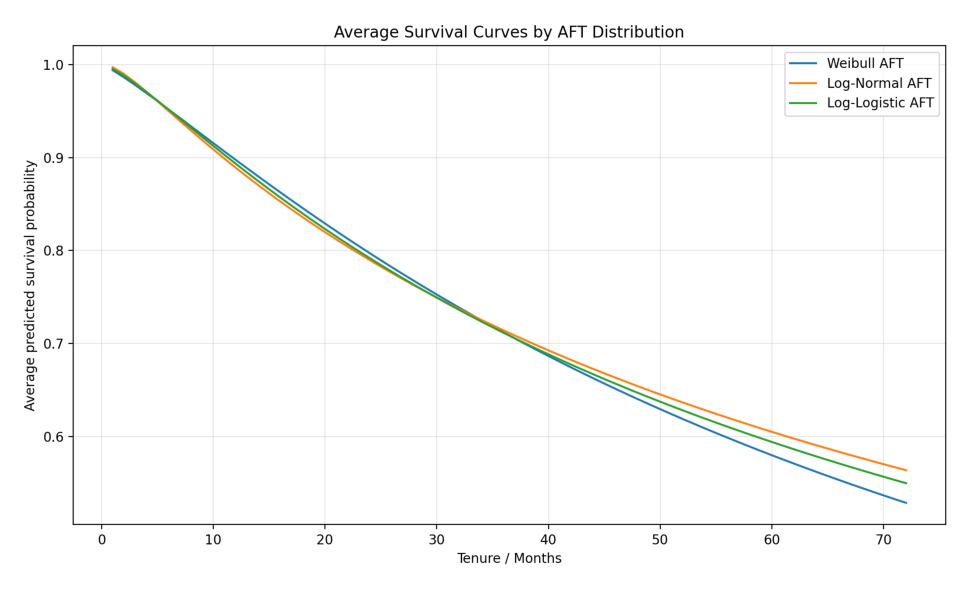

In [5]:
img = mpimg.imread(IMG_DIR / "aft_survival_curves.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Final Model and Feature Selection

**Model selection rule:** Among models within 2 AIC points of the best, prefer the simpler and more interpretable distribution.  
→ **Log-Normal AFT** selected.

I focused on the standard AFT-style parametric regression models available in lifelines. Piecewise exponential regression was not included because it requires externally specified breakpoints rather than a single distributional AFT form.

The log-normal hazard is non-monotonic (initially rising then falling) — a plausible shape for telecom churn, where risk peaks as initial contracts mature and then declines as loyal subscribers dominate.

Predictors kept: statistically significant at α = 0.05.

In [6]:
final_summary = pd.read_csv(OUTPUT_DIR / "final_model_summary.csv")
display(final_summary)

,param,covariate,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
0,mu_,address,0.042824,1.043754,0.008847,0.025483,0.060164,1.025811,1.062011,0.0,4.840293,1.296478e-06,19.556971
1,mu_,age,0.036826,1.037512,0.006400,0.024283,0.049369,1.024580,1.050608,0.0,5.754395,8.695261e-09,26.777123
2,mu_,custcat_E-service,1.025825,2.789395,0.169047,0.694499,1.357150,2.002706,3.885105,0.0,6.068295,1.292752e-09,29.526907
3,mu_,custcat_Plus service,0.822553,2.276303,0.169425,0.490485,1.154620,1.633109,3.172818,0.0,4.854960,1.204113e-06,19.663598
4,mu_,custcat_Total service,1.013269,2.754590,0.209579,0.602501,1.424036,1.826682,4.153852,0.0,4.834781,1.332924e-06,19.516974
5,mu_,internet_Yes,-0.840528,0.431483,0.138259,-1.111511,-0.569545,0.329061,0.565783,0.0,-6.079365,1.206593e-09,29.626414
6,mu_,marital_Unmarried,-0.447317,0.639341,0.114472,-0.671679,-0.222956,0.510850,0.800150,0.0,-3.907654,9.319665e-05,13.389362
7,mu_,voice_Yes,-0.463493,0.629082,0.166771,-0.790359,-0.136628,0.453682,0.872294,0.0,-2.779221,5.448947e-03,7.519807
8,mu_,Intercept,2.534887,12.615010,0.242611,2.059379,3.010396,7.841100,20.295430,0.0,10.448373,1.490611e-25,82.472298
9,sigma_,Intercept,0.283034,1.327150,0.046020,0.192836,0.373231,1.212684,1.452420,0.0,6.150258,7.735690e-10,30.267751


## 5. Coefficient Interpretation

In an AFT model:
- **Positive coef** → longer expected survival → lower churn speed  
- **Negative coef** → shorter expected survival → faster churn  
- **Time ratio = exp(coef)**: > 1 extends survival; < 1 compresses it

In [7]:
coef_table = pd.read_csv(OUTPUT_DIR / "coefficient_interpretation.csv")
display(coef_table.style.format({
    "coef": "{:.4f}",
    "time_ratio_exp_coef": "{:.4f}",
    "p": "{:.2e}",
}).bar(subset=["coef"], align="zero", color=["#d65f5f", "#5fba7d"]))

,param,covariate,coef,time_ratio_exp_coef,p,direction
0,mu_,internet_Yes,-0.8405,0.4315,1.21e-09,shorter survival / higher churn speed
1,mu_,custcat_E-service,1.0258,2.7894,1.29e-09,longer survival / lower churn speed
2,mu_,age,0.0368,1.0375,8.70e-09,longer survival / lower churn speed
3,mu_,custcat_Plus service,0.8226,2.2763,1.20e-06,longer survival / lower churn speed
4,mu_,address,0.0428,1.0438,1.30e-06,longer survival / lower churn speed
5,mu_,custcat_Total service,1.0133,2.7546,1.33e-06,longer survival / lower churn speed
6,mu_,marital_Unmarried,-0.4473,0.6393,9.32e-05,shorter survival / higher churn speed
7,mu_,voice_Yes,-0.4635,0.6291,5.45e-03,shorter survival / higher churn speed


| Feature | Time ratio | Interpretation |
|---|---|---|
| `custcat_E-service` | ≈ 2.79 | E-service subscribers survive ~2.8× longer than Basic service |
| `custcat_Total service` | ≈ 2.75 | Total service subscribers survive ~2.75× longer than Basic |
| `custcat_Plus service` | ≈ 2.28 | Plus service subscribers survive ~2.3× longer than Basic |
| `internet_Yes` | ≈ 0.43 | Internet subscribers churn ~2.3× faster — more competitive alternatives, lower switching costs |
| `voice_Yes` | ≈ 0.63 | Voice service associated with faster churn — may reflect plan structure, customer type, or lower switching costs; interpreted as association, not causal |
| `marital_Unmarried` | ≈ 0.64 | Unmarried subscribers churn faster — higher mobility, fewer household switching costs |
| `age` | ≈ 1.04 per year | Older subscribers stay longer — higher inertia |
| `address` | ≈ 1.04 per year | Longer residential stability → lower churn speed |

## 6. Customer-Level CLV

CLV estimated using conditional survival:

$$CLV_i = \sum_{m=1}^{36} \frac{\$30 \cdot S(t_i + m) \,/\, S(t_i)}{(1 + 0.10/12)^m}$$

Monthly margin = $30 (constant; subscriber income is not company revenue).  
Horizon = 36 months. Annual discount rate = 10%.

In [8]:
clv_df = pd.read_csv(OUTPUT_DIR / "customer_clv.csv")
print("CLV (36-month horizon) summary:")
print(clv_df["clv_36m"].describe().apply(lambda x: f"${x:,.2f}"))
clv_df.head(10)

CLV (36-month horizon) summary:
count    $1,000.00
mean       $785.33
std        $108.74
min        $238.65
25%        $726.68
50%        $808.04
75%        $870.44
max        $928.16
Name: clv_36m, dtype: object


,ID,tenure,predicted_survival_12m,predicted_churn_risk_12m,clv_36m,at_risk_12m,region,marital,ed,retire,gender,voice,internet,forward,custcat
0,1,13,0.901952,0.098048,802.960804,0,Zone 2,Married,College degree,No,Male,No,No,Yes,Basic service
1,2,11,0.909187,0.090813,810.554982,0,Zone 3,Married,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service
2,3,68,0.983306,0.016694,906.834968,0,Zone 3,Married,Did not complete high school,No,Female,No,No,No,Plus service
3,4,33,0.844947,0.155053,741.015155,1,Zone 2,Unmarried,High school degree,No,Female,No,No,No,Basic service
4,5,23,0.926138,0.073862,833.203869,0,Zone 2,Married,Did not complete high school,No,Male,No,No,Yes,Plus service
5,6,41,0.940841,0.059159,852.191744,0,Zone 2,Unmarried,High school degree,No,Female,No,No,No,Plus service
6,7,45,0.844036,0.155964,739.662751,1,Zone 3,Married,High school degree,No,Female,No,Yes,No,E-service
7,8,38,0.806640,0.193360,699.422506,1,Zone 2,Unmarried,High school degree,No,Male,Yes,Yes,Yes,Total service
8,9,45,0.972875,0.027125,892.724241,0,Zone 3,Married,College degree,No,Male,No,No,Yes,Plus service
9,10,68,0.975550,0.024450,896.642194,0,Zone 1,Married,Did not complete high school,No,Male,No,No,No,E-service


## 7. Segment-Level CLV Analysis

**Definition of valuable segment:** High average 36-month CLV **and** commercially meaningful size.

In [9]:
segment_summary = pd.read_csv(OUTPUT_DIR / "segment_clv_summary.csv")

print("Top segments by mean CLV:")
display(segment_summary.head(10))

print("\nRiskiest segments by 12-month churn risk:")
display(segment_summary.sort_values("mean_churn_risk_12m", ascending=False).head(10))

Top segments by mean CLV:


,segment_value,n_customers,mean_clv_36m,median_clv_36m,mean_churn_risk_12m,at_risk_customers,segment_variable,segment
0,Yes,47,895.167613,906.223377,0.025313,0,retire,retire = Yes
1,Plus service,281,841.624309,856.661509,0.069379,30,custcat,custcat = Plus service
2,Did not complete high school,204,826.321448,852.456443,0.083770,34,ed,ed = Did not complete high school
3,E-service,217,825.251775,835.324298,0.083507,36,custcat,custcat = E-service
4,No,632,820.310105,842.567024,0.088373,122,internet,internet = No
5,Married,495,811.706258,831.545454,0.096076,94,marital,marital = Married
6,Yes,493,803.124366,825.983030,0.103976,123,forward,forward = Yes
7,No,696,797.765600,822.978696,0.109462,186,voice,voice = No
8,High school degree,287,792.856410,825.714293,0.114538,83,ed,ed = High school degree
9,Zone 2,334,790.151829,817.389631,0.116249,101,region,region = Zone 2



Riskiest segments by 12-month churn risk:


,segment_value,n_customers,mean_clv_36m,median_clv_36m,mean_churn_risk_12m,at_risk_customers,segment_variable,segment
23,Basic service,266,711.118986,732.533384,0.190783,152,custcat,custcat = Basic service
22,Yes,368,725.251246,746.395594,0.176524,183,internet,internet = Yes
21,College degree,234,756.013889,775.800712,0.147382,92,ed,ed = College degree
20,Yes,304,756.853906,775.971054,0.146800,119,voice,voice = Yes
19,Unmarried,505,759.472966,782.754940,0.145059,211,marital,marital = Unmarried
18,Post-undergraduate degree,66,763.768631,783.623097,0.137925,26,ed,ed = Post-undergraduate degree
17,Total service,236,765.231902,779.289443,0.137490,87,custcat,custcat = Total service
16,No,507,768.023931,789.829078,0.137184,182,forward,forward = No
15,Some college,209,774.608135,792.792290,0.130433,70,ed,ed = Some college
14,Zone 3,344,779.873111,805.515925,0.126132,112,region,region = Zone 3


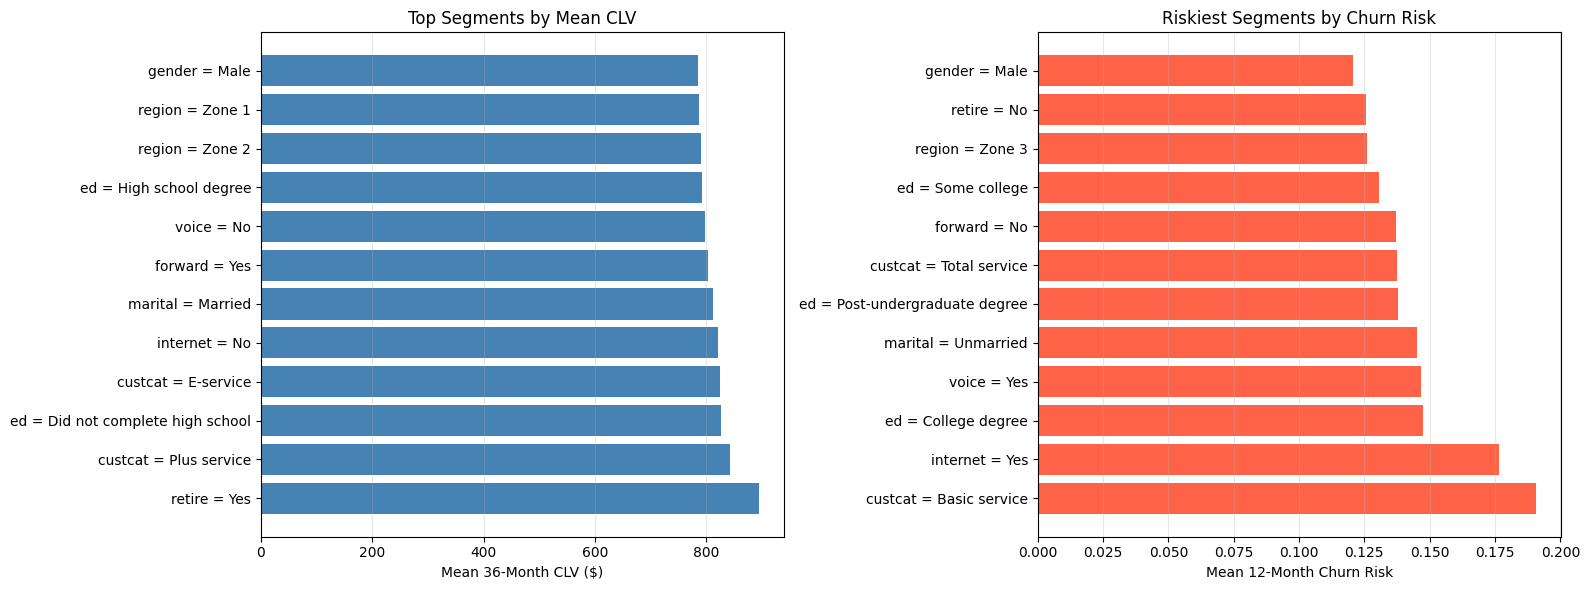

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_clv = segment_summary.head(12)
axes[0].barh(top_clv["segment"], top_clv["mean_clv_36m"], color="steelblue")
axes[0].set_xlabel("Mean 36-Month CLV ($)")
axes[0].set_title("Top Segments by Mean CLV")
axes[0].grid(axis="x", alpha=0.3)

top_risk = segment_summary.sort_values("mean_churn_risk_12m", ascending=False).head(12)
axes[1].barh(top_risk["segment"], top_risk["mean_churn_risk_12m"], color="tomato")
axes[1].set_xlabel("Mean 12-Month Churn Risk")
axes[1].set_title("Riskiest Segments by Churn Risk")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Annual Retention Budget

**At-risk definition:** Predicted 12-month churn probability ≥ 15%.  
**Budget logic:** 25% of expected CLV exposed to churn — not every retention contact succeeds.

In [11]:
budget = pd.read_csv(OUTPUT_DIR / "retention_budget.csv")
b = budget.iloc[0]

print(f"Total customers:          {int(b['n_customers']):>8,}")
print(f"At-risk customers:        {int(b['n_at_risk_customers']):>8,}  ({b['share_at_risk']:.1%} of base)")
print(f"Expected CLV at risk:     {b['expected_clv_at_risk']:>10,.2f} USD")
print(f"Recommended budget:       {b['recommended_annual_retention_budget']:>10,.2f} USD")
display(budget)

Total customers:             1,000
At-risk customers:             305  (30.5% of base)
Expected CLV at risk:      46,004.04 USD
Recommended budget:        11,501.01 USD


,n_customers,at_risk_threshold_12m,n_at_risk_customers,share_at_risk,expected_clv_at_risk,recommended_annual_retention_budget,retention_spend_share_of_expected_clv_at_risk
0,1000,0.15,305,0.305,46004.040707,11501.010177,0.25


## 9. Report

### Model Selection

All three converged AFT models produced similar concordance indices (~0.787), confirming distribution choice has limited impact here. Log-Normal AFT was selected because it had the lowest AIC and BIC among the converged models. The concordance index difference vs. Log-Logistic was negligible (< 0.0001), confirming the distributions perform equivalently on this data. The log-normal hazard is non-monotonic — initially increasing then decreasing — which is a plausible shape for subscriber churn: risk is low at first, peaks as contracts mature, then declines as highly loyal subscribers dominate the surviving cohort.

### Factors Affecting Churn Risk

The strongest churn determinant is **customer category**. E-service and Total service subscribers survive roughly 2.8× and 2.75× longer than Basic service subscribers respectively. Basic service is both the riskiest segment (mean 12-month churn risk ≈ 19%) and the one with the most at-risk customers. Basic service customers should be prioritized for targeted retention analysis and possible plan-upgrade offers, but the effect of upselling itself would require separate testing to confirm.

**Internet service** is associated with faster churn (time ratio ≈ 0.43). Subscribers with internet access have more competitive alternatives and lower switching costs in a more contested broadband market.

**Voice service** also shows faster churn (time ratio ≈ 0.63). Counterintuitively, voice service is associated with shorter survival. This may reflect plan structure, customer type, or lower switching costs among voice-service users — I interpret this as an association, not a causal effect.

**Demographic factors**: older age and longer residential tenure slow churn, consistent with higher inertia. Unmarried subscribers churn faster due to higher mobility and fewer household-level dependencies.

### Most Valuable Segments

Valuable = **high mean 36-month CLV** + **low churn risk** + **commercially meaningful size**.

Top segments are retired subscribers, Plus service, E-service, and Total service customers — all with mean CLV above $820 and very few at-risk subscribers. These are already loyal; retention investment has low ROI here. The priority is protecting them from accidental churn (service failures, billing errors).

### At-Risk Subscribers and Retention Budget

Using a 15% 12-month churn risk threshold, **305 out of 1,000 subscribers** are at risk (30.5% of the base). The expected CLV exposed to churn is approximately **$46,004**. A defensible annual retention budget is **25% of that figure — $11,501** — reflecting that not every retention intervention succeeds.

### Additional Retention Suggestions

- **Plan upgrade offers**: Basic service customers show the highest churn risk and should be prioritized for plan-upgrade outreach. Whether upselling reduces churn would require A/B testing to confirm causality.
- **Targeted offers, not blanket discounts**: High-CLV, high-risk customers warrant strong retention offers or proactive service recovery. Low-CLV, high-risk customers should receive cheaper digital interventions (plan reminders, usage summaries).
- **Internet segment**: Requires competitive pricing or loyalty benefits to offset higher churn tendency.
- **Young, unmarried subscribers**: Targeted plan flexibility or multi-line household discounts may reduce switching propensity.